# Section 4.2


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from utils.log_print import LogPrint
from configs.base.env_cfg import device, torch_dtype
from utils.model_saver import (
    load_market_and_critic0,
    load_actor,
    load_critic_lambda
)
from src.rl_models import q_diff_risk_lambda, q_diff_critic_risk_lambda
from utils.pricing.pvv_bs_model import PVVBSModel
from src.bs_model import sim_bs_paths_cfg

from src.data_processing import make_state_t
from src.rl_models import extract_theta_from_outputs

In [ ]:
# =============================================================================
# Configuration
# =============================================================================

LOAD_DIR = "models/bs_0_2_mu_0_3"
LOAD_DIR = "models/4_2_bs_0_2"
# LOAD_DIR = "models/5_1_bs_0_2_mu_0_08"
ACTOR_LAMBDA = 100000.0

# Moneyness and maturity cross-sections
# K_GRID = np.linspace(70.0, 130.0, 50)
K_GRID = [100]
# TAU_GRID = [0.25]
LAMBDA_GRID = [
    0, 0.01, 0.1, 1.0, 10.0, 20.0, 50
]

all_actions = np.linspace(-1.0,0, 50)


In [ ]:
# =============================================================================
# Load market, actor, critic0
# =============================================================================
log_print = LogPrint(
    print_debug=True,
    save_dir=os.path.join(LOAD_DIR, "logs"),
    prefix="analysis_section_4_1",
)
critic0, market_cfg, critic0_cfg, runtime_cfg = load_market_and_critic0(
    log_print=log_print,
    load_dir=LOAD_DIR,
    device=device,
    torch_dtype=torch_dtype,
)

actor, actor_cfg = load_actor(
    log_print=log_print,
    load_dir=LOAD_DIR,
    actor_lambda=ACTOR_LAMBDA,
    device=device,
    torch_dtype=torch_dtype,
)

actor.eval()
for p in actor.parameters():
    p.requires_grad_(False)


In [4]:
# ============================================================
# Market config (BS)
# ============================================================

S0 = market_cfg.S0
mu = market_cfg.mu          # risk-neutral: mu = r
r = market_cfg.r
sigma = market_cfg.sigma

T = market_cfg.T
T_steps = market_cfg.T_steps
dt = market_cfg.dt

K = S0
option_type = market_cfg.option_type
transaction_cost_rate = market_cfg.transaction_cost_rate

# ============================================================
# Simulate BS paths
# ============================================================
N_paths = 1

S_paths_t, log_returns, _ = sim_bs_paths_cfg(
    s_cfg=market_cfg,
    N_paths=N_paths,
    T_steps=T_steps,
)

# torch -> numpy
S_paths = S_paths_t.cpu().numpy()

# ============================================================
# tau vector
# ============================================================
tau_vec = T - np.arange(T_steps + 1) * float(dt)
tau_vec = np.maximum(tau_vec, 1e-6)

# ============================================================
# BS benchmark price & delta (PVV)
# ============================================================
bs_pricer = PVVBSModel(market_cfg)

S_mat = S_paths[:, :-1]  # (N, T)
K_mat = np.full_like(S_mat, K)

price_mat, delta_mat_bs = bs_pricer.price_and_delta(
    S_mat=S_mat,
    K_mat=K_mat,
    tau_vec=tau_vec[:-1],
)

# assemble delta paths (including maturity)
delta_paths_bs = np.zeros_like(S_paths)
delta_paths_bs[:, :-1] = delta_mat_bs

if option_type == "call":
    delta_T = (S_paths[:, -1] > K).astype(float)
else:
    delta_T = -(S_paths[:, -1] < K).astype(float)

delta_paths_bs[:, -1] = delta_T
# ============================================================
# Initial option price (BS)
# ============================================================
initial_option_price = price_mat[:, 0].mean()


In [5]:

@torch.no_grad()
def acc_slice(
        actor, critic0, critic,
        S0,
        K_GRID,
        all_actions,
        actor_risk_lambda: float,
        all_critic_risk_lambda: list,
        t,
        device, torch_dtype,
):
    K_GRID = torch.tensor(K_GRID, device=device, dtype=torch_dtype)
    S_over_K = S0 / K_GRID
    state = make_state_t(
        torch.tensor(S_over_K, device=device, dtype=torch_dtype),
        torch.tensor(t, device=device, dtype=torch_dtype),
    )
    actions = actor.mean(state)

    actions = torch.tensor(all_actions, device=device, dtype=torch_dtype)
    state.repeat(50, 1, 1)

    Q0 = critic0(state, actions)

    QQ = q_diff_critic_risk_lambda(
        critic0=critic0,
        critic=critic,
        actions=actions,
        actor_risk_lambda=actor_risk_lambda,
        all_critic_risk_lambda=all_critic_risk_lambda,
        state=state,
    )

    return - QQ * K_GRID

In [6]:
with torch.no_grad():
    critic, _ = load_critic_lambda(
            log_print=log_print,
            load_dir=LOAD_DIR,
            actor_lambda=ACTOR_LAMBDA,
            critic_lambda=ACTOR_LAMBDA,
            device=device,
            torch_dtype=torch_dtype,
    )

[CriticLoader] Loaded critic λ=100000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_100000.0000.pt
  device: mps


In [7]:
with torch.no_grad():
    T_mat = (
        torch.tensor(tau_vec[:-1], device=device, dtype=torch_dtype)
        .unsqueeze(0)
        .expand(N_paths, T_steps)
    )
    all_q = acc_slice(
        actor, critic0, critic,
        S0,
        K_GRID,
        all_actions,
        actor_risk_lambda = ACTOR_LAMBDA,
        all_critic_risk_lambda = LAMBDA_GRID,
        t = tau_vec[0],
        device=device,
        torch_dtype=torch_dtype,
    )[:,0]


/var/folders/sl/0y225v_53s51ql32byt5jkcm0000gn/T/ipykernel_77120/1803360376.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(S_over_K, device=device, dtype=torch_dtype),


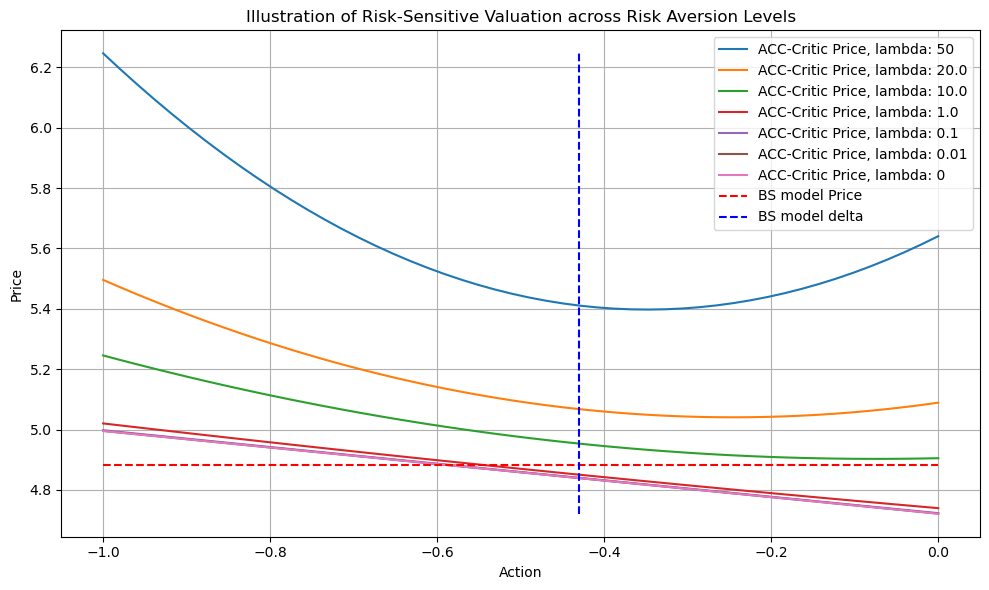

np.float64(4.882221902473722)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 创建画布
plt.figure(figsize=(10, 6))

all_q_np = all_q.detach().cpu().numpy()

# 循环画 9 条线
for i in reversed(range(len(all_q_np))):
    l = LAMBDA_GRID[i]
    plt.plot(all_actions, all_q_np[i], label=f'ACC-Critic Price, lambda: {l}')


plt.plot(
    all_actions, np.repeat(initial_option_price, 50),
    label=f'BS model Price', color='red', linestyle='dashed')
plt.plot(
    np.repeat(delta_mat_bs[0, 0], 50), np.linspace(all_q_np.min(), all_q_np.max(), 50),
    label=f'BS model delta', color='blue', linestyle='dashed')
# 标注
plt.xlabel('Action')
plt.ylabel('Price')
plt.title('Illustration of Risk‑Sensitive Valuation across Risk Aversion Levels')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()
initial_option_price

In [ ]:
print()